In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
DATA_DIR = Path(r"C:\Users\karth\Downloads\CMIP_Models")
OUT_PNG = DATA_DIR / "held_soden_fig6_cmip6.png"

In [4]:
MODELS = [
    "ACCESS-CM2",
    "BCC-CSM2-MR",
    "CESM2",
    "CMCC-CM2-SR5",
    "CNRM-CM6-1",
    "CanESM5",
    "EC-Earth3",
    "GFDL-ESM4",
    "IPSL-CM6A-LR",
    "MPI-ESM1-2-LR",
]

ALPHA = 0.07
SEC_PER_DAY = 86400.0
COMMON_LAT = np.arange(-90, 90.1, 2.5)

PERIODS = {
    "historical": {
        "early": ("1900", "1919"),
        "late":  ("1995", "2014"),
    },
    "ssp370": {
        "early": ("2015", "2034"),
        "late":  ("2081", "2100"),
    },
}


In [5]:
def find_paths(var, model, experiment):
    paths = sorted(DATA_DIR.rglob(f"{var}_Amon_{model}_{experiment}_*.nc"))
    if not paths:
        raise FileNotFoundError(
            f"Missing {var} file for {model} {experiment}. "
            f"Expected something like {var}_Amon_{model}_{experiment}_*.nc"
        )

    preferred = [p for p in paths if "_r1i1p1f1_" in p.name]
    return preferred if preferred else paths


In [6]:

def open_da(var, model, experiment):
    paths = find_paths(var, model, experiment)
    paths = [str(p) for p in paths]

    if len(paths) == 1:
        ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
    else:
        ds = xr.open_mfdataset(
            paths,
            combine="by_coords",
            decode_times=True,
            use_cftime=True,
        )

    if var not in ds:
        raise KeyError(f"{var} not found inside {paths[0]}")

    return ds[var]


def coord_name(da, choices):
    for name in choices:
        if name in da.dims or name in da.coords:
            return name
    raise ValueError(f"Could not find any of {choices} in {list(da.dims)}")


def lat_name(da):
    return coord_name(da, ["lat", "latitude"])


def lon_name(da):
    return coord_name(da, ["lon", "longitude"])


def period_mean(da, period): #This function selects the time period and averages over time
    start, end = period
    out = da.sel(time=slice(start, end)).mean("time", skipna=True)
    return out


def global_mean(da):
    la = lat_name(da)
    lo = lon_name(da)
    weights = np.cos(np.deg2rad(da[la])) #The global mean uses cosine latitude weighting. This is needed because grid cells near the equator cover more area than grid cells near the poles
    return float(da.weighted(weights).mean((la, lo), skipna=True).values)


def zonal_mean(da):
    return da.mean(lon_name(da), skipna=True)


def to_common_lat(da):
    la = lat_name(da)
    da = da.sortby(la)
    out = da.interp({la: COMMON_LAT})

    if la != "lat":
        out = out.rename({la: "lat"})

    return out


def calc_model(model, experiment):
    early = PERIODS[experiment]["early"]
    late = PERIODS[experiment]["late"]

    tas = open_da("tas", model, experiment)
    pr = open_da("pr", model, experiment)
    evspsbl = open_da("evspsbl", model, experiment)

    tas_early = period_mean(tas, early)
    tas_late = period_mean(tas, late)

    pr_early = period_mean(pr, early)
    pr_late = period_mean(pr, late)

    ev_early = period_mean(evspsbl, early)
    ev_late = period_mean(evspsbl, late)

    dt = tas_late - tas_early #Temperature change
    dT_global = global_mean(dt) #global mean warming

    pe_early = (pr_early - ev_early) * SEC_PER_DAY #The actual P−E change mm/day
    pe_late = (pr_late - ev_late) * SEC_PER_DAY

    actual = to_common_lat(zonal_mean(pe_late - pe_early)) / dT_global #The hydrological change per 1 K of global warming

    predicted = ( #dashed line is calculated here
        ALPHA 
        * to_common_lat(zonal_mean(dt))
        * to_common_lat(zonal_mean(pe_early))
        / dT_global
    ) #Where the original climate was wet, the prediction says it becomes wetter, and where the original climate was dry, the prediction says it becomes drier. The dashed line is the predicted change in P−E per 1 K of global warming based on the Clausius-Clapeyron relation and the assumption that relative humidity stays constant.

    return actual, predicted, dT_global

In [7]:
def clean_for_concat(da):
    """
    Remove scalar/non-dimension coordinates such as 'height'
    so that different models can be concatenated safely.
    Keeps the latitude dimension coordinate.
    """
    da = da.squeeze(drop=True)
    da = da.reset_coords(drop=True)
    return da
#It does not change the actual plotted values of Δ(P−E). It only cleans metadata so that this line can work:
#This often appears in tas because tas means near-surface air temperature at 2 m height. But not every model stores this coordinate in the same way.

In [8]:
def calc_ensemble(experiment):
    actuals = []
    predicted = []
    used_models = []
    skipped = []

    for model in MODELS:
        try:
            actual, pred, dT = calc_model(model, experiment)

            actual = clean_for_concat(actual)
            pred = clean_for_concat(pred)

            actuals.append(actual)
            predicted.append(pred)
            used_models.append(model)

            print(f"{experiment:10s} {model:16s} used, global ΔT = {dT:.3f} K")

        except Exception as e:
            skipped.append((model, str(e)))
            print(f"{experiment:10s} {model:16s} skipped: {e}")

    if not actuals:
        raise RuntimeError(f"No models could be processed for {experiment}")

    model_dim = xr.DataArray(used_models, dims="model", name="model")

    actual_all = xr.concat(
        actuals,
        dim=model_dim,
        coords="minimal",
        compat="override",
    )

    predicted_all = xr.concat(
        predicted,
        dim=model_dim,
        coords="minimal",
        compat="override",
    )

    actual_ens = actual_all.mean("model", skipna=True)
    predicted_ens = predicted_all.mean("model", skipna=True)

    # spread across models
    actual_std = actual_all.std("model", skipna=True)
    predicted_std = predicted_all.std("model", skipna=True)

    return actual_ens, predicted_ens, actual_std, predicted_std, used_models, skipped

In [10]:
# Plot controls

FIXED_HS_SCALE = False #Let the code automatically choose the y-axis range so all curves fit inside the grid.
HS_YLIM = 0.20 #plot range becomes -0.20 to 0.20, which is the same as the original Held & Soden figure. 

# Use 1 for no smoothing; 3 is mild and helps a 10-model CMIP6 ensemble look like the paper figure.
LAT_SMOOTH_WINDOW = 3 #A value of 3 means the code uses a moving average over 3 latitude points.


def smooth_lat(da, window=1):
    """Smooth only for plotting. The ensemble calculation is unchanged."""
    if window is None or window <= 1:
        return da
    return da.rolling(lat=window, center=True, min_periods=1).mean() #replace each latitude value with the average of nearby latitude values


def nice_symmetric_ylim(series, minimum=0.2, step=0.1, pad=1.08): #1. all plotted values fit inside the graph,2. the y-axis is symmetric around zero, 3. the limit is rounded nicely
    """Return a symmetric y-axis limit large enough to include all curves."""
    max_abs = 0.0
    for da in series:
        vals = np.asarray(da.values, dtype=float)
        if np.isfinite(vals).any():
            max_abs = max(max_abs, float(np.nanmax(np.abs(vals))))

    ymax = max(minimum, np.ceil((max_abs * pad) / step) * step)
    return float(ymax)


def apply_common_yaxis(axes, series):
    """Use the same y-axis for both panels, but do not clip the curves."""
    if FIXED_HS_SCALE:
        ymax = HS_YLIM
    else:
        ymax = nice_symmetric_ylim(series, minimum=HS_YLIM, step=0.1, pad=1.08)

    

    for ax in axes:
        ax.set_ylim(-ymax, ymax)
        ax.set_yticks([-0.2, -0.1, 0.0, 0.1, 0.2])
        ax.set_yticklabels(["-0.2", "-0.1", "0", "0.1", "0.2"])
        ax.grid(True, which="major", alpha=0.30)
        ax.set_axisbelow(True)

ACTUAL_COLOR = "royalblue"
PRED_COLOR = "darkorange"
GRID_COLOR = "lightgray"
ZERO_LINE_COLOR = "gray"

def plot_panel(ax, actual, predicted, actual_std, predicted_std, title):
    actual_plot = smooth_lat(actual, LAT_SMOOTH_WINDOW)
    pred_plot = smooth_lat(predicted, LAT_SMOOTH_WINDOW)

    actual_std_plot = smooth_lat(actual_std, LAT_SMOOTH_WINDOW)
    pred_std_plot = smooth_lat(predicted_std, LAT_SMOOTH_WINDOW)

    lat = actual_plot["lat"].values

    actual_mean = actual_plot.values
    actual_upper = (actual_plot + actual_std_plot).values
    actual_lower = (actual_plot - actual_std_plot).values

    pred_mean = pred_plot.values
    pred_upper = (pred_plot + pred_std_plot).values
    pred_lower = (pred_plot - pred_std_plot).values

    # Shaded band for CMIP6 ensemble
    ax.fill_between(
        lat,
        actual_lower,
        actual_upper,
        color="tab:blue",
        alpha=0.20
    )

    # Shaded band for thermodynamic prediction
    ax.fill_between(
        lat,
        pred_lower,
        pred_upper,
        color="tab:orange",
        alpha=0.20
    )

    # Mean lines
    ax.plot(
        lat,
        actual_mean,
        color="tab:blue",
        lw=2.5,
        label="CMIP6 ensemble"
    )

    ax.plot(
        lat,
        pred_mean,
        color="tab:orange",
        lw=2.5,
        ls="--",
        label="Thermodynamic prediction"
    )

    ax.axhline(0, color="0.4", lw=0.9)

    ax.set_xlim(-90, 90)
    ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
    ax.set_xticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])
    ax.set_xlabel("Latitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    return actual_plot, pred_plot


In [ ]:
# def plot_panel(ax, actual, predicted, title):
#     ax.plot(actual["lat"], actual, color="black", lw=2.0, label="CMIP6 ensemble")
#     ax.plot(
#         predicted["lat"],
#         predicted,
#         color="black",
#         lw=2.0,
#         ls="--",
#         label="Thermodynamic prediction",
#     )
#     ax.axhline(0, color="0.4", lw=0.8)
#     ax.set_xlim(-90, 90)
#     ax.set_ylim(-0.2, 0.2)

#     ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
#     ax.set_xticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

#     ax.set_xlabel("Latitude")
#     ax.set_title(title)
#     ax.grid(True, alpha=0.25)

In [ ]:
# def plot_panel(ax, actual, predicted, title):
#     actual_plot = smooth_lat(actual, LAT_SMOOTH_WINDOW)
#     pred_plot = smooth_lat(predicted, LAT_SMOOTH_WINDOW)

#     ax.plot(
#         actual_plot["lat"],
#         actual_plot,
#         color="royalblue",
#         lw=3.0,
#         label="CMIP6 ensemble",
#     )

#     ax.plot(
#         pred_plot["lat"],
#         pred_plot,
#         color="darkorange",
#         lw=3.0,
#         ls="--",
#         label="Thermodynamic prediction",
#     )

#     ax.axhline(0, color="gray", lw=2.0)
#     ax.set_xlim(-90, 90)
#     ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
#     ax.set_xticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])
#     ax.set_xlabel("Latitude")
    
#     ax.set_title(title)
#     ax.grid(True, alpha=0.30)
#     ax.set_axisbelow(True)

C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

historical ACCESS-CM2       used, global ΔT = 0.714 K


C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

historical BCC-CSM2-MR      used, global ΔT = 0.702 K


c:\Users\karth\miniconda3\envs\scikit\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:8: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
c:\Users\karth\miniconda3\envs\scikit\lib\site-packages\xarray\conventions.py:204: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:8: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Pl

...

ssp370     GFDL-ESM4        used, global ΔT = 2.198 K


C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_dataset(paths[0], decode_times=True, use_cftime=True)
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:6: DeprecationWarning: Usage of 'use_cftime' as a kwarg is d

ssp370     IPSL-CM6A-LR     used, global ΔT = 3.210 K


C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:8: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:8: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(
C:\Users\karth\AppData\Local\Temp\ipykernel_20176\3350939350.py:8: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to t

ssp370     MPI-ESM1-2-LR    used, global ΔT = 2.113 K


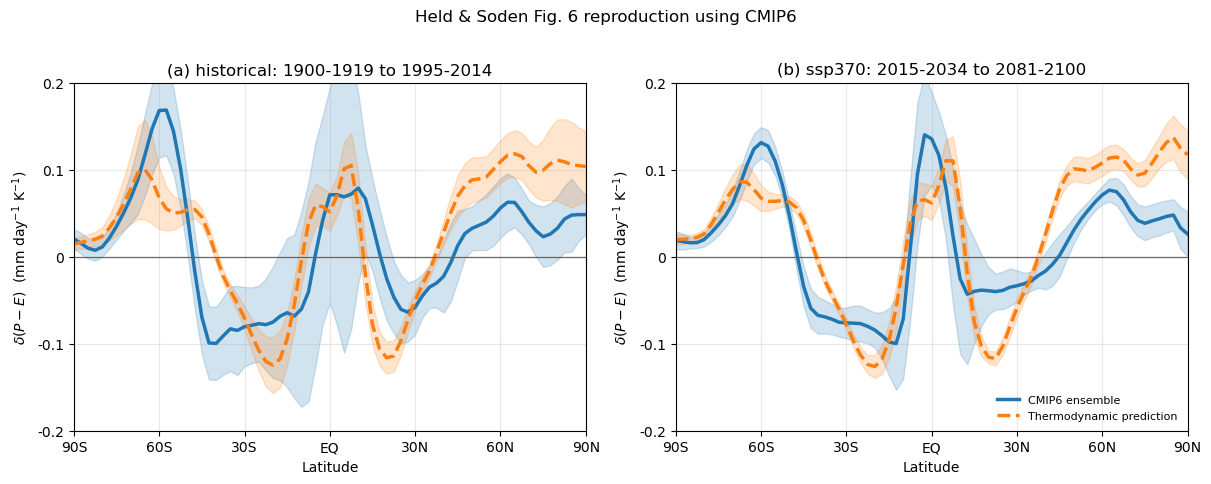


Saved figure to: C:\Users\karth\Downloads\CMIP_Models\held_soden_fig6_cmip6.png
Historical models used: ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5', 'EC-Earth3', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR']
SSP370 models used: ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CMCC-CM2-SR5', 'CNRM-CM6-1', 'CanESM5', 'EC-Earth3', 'GFDL-ESM4', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR']


In [11]:
def main():
    hist_actual, hist_pred, hist_actual_std, hist_pred_std, hist_models, hist_skipped = calc_ensemble("historical")
    fut_actual, fut_pred, fut_actual_std, fut_pred_std, fut_models, fut_skipped = calc_ensemble("ssp370")

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4.8),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    hist_actual_plot, hist_pred_plot = plot_panel(
        axes[0],
        hist_actual,
        hist_pred,
        hist_actual_std,
        hist_pred_std,
        "(a) historical: 1900-1919 to 1995-2014",
    )

    fut_actual_plot, fut_pred_plot = plot_panel(
        axes[1],
        fut_actual,
        fut_pred,
        fut_actual_std,
        fut_pred_std,
        "(b) ssp370: 2015-2034 to 2081-2100",
    )

    # same dimensions and same axis formatting
    for ax in axes:
        ax.set_xlim(-90, 90)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.set_xticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])
        ax.set_ylim(-0.2, 0.2)
        ax.set_yticks([-0.2, -0.1, 0.0, 0.1, 0.2])
        ax.set_yticklabels(["-0.2", "-0.1", "0", "0.1", "0.2"])
        ax.set_box_aspect(0.68)

    axes[0].set_ylabel(r"$\delta(P-E)$  (mm day$^{-1}$ K$^{-1}$)")
    axes[1].tick_params(axis="y", labelleft=True)
    axes[1].set_ylabel(r"$\delta(P-E)$  (mm day$^{-1}$ K$^{-1}$)")

    axes[1].legend(frameon=False, loc="lower right", fontsize=8)

    fig.suptitle("Held & Soden Fig. 6 reproduction using CMIP6")
    fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
    plt.show()

    print("\nSaved figure to:", OUT_PNG)
    print("Historical models used:", hist_models)
    print("SSP370 models used:", fut_models)

    if hist_skipped or fut_skipped:
        print("\nSkipped models:")
        for item in hist_skipped + fut_skipped:
            print(item)


if __name__ == "__main__":
    main()